In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
df_daily= pd.read_parquet('../dataset/processed_data_daily.parquet')

In [32]:
import holidays
from datetime import timedelta

vn_holidays= holidays.Vietnam(years=range(2012, 2025))
retail_holidays = ['02-14', '10-31', '12-24', '12-25', '12-31', '06-01']
black_friday_dates = [
    '2012-11-23', '2013-11-29', '2014-11-28', '2015-11-27', 
    '2016-11-25', '2017-11-24', '2018-11-23', '2019-11-29', 
    '2020-11-27', '2021-11-26', '2022-11-25', '2023-11-24', '2024-11-29'
]
double_days = ['01-01', '02-02', '03-03', '04-04', '05-05', '06-06', 
               '07-07', '08-08', '09-09', '10-10', '11-11', '12-12']
def get_special_event(date):
    if date in vn_holidays:
        return 1
    if date.strftime('%m-%d') in retail_holidays:
        return 1
    if date.strftime('%Y-%m-%d') in black_friday_dates:
        return 1
    if date.year >= 2017 and date.strftime('%m-%d') in double_days:
        return 1
    return 0
# Daily Aggregation: Nén dữ liệu về dạng Ngày
def get_pre_holiday_event(date):
    for i in range(1, 8):
        future_date = date + pd.Timedelta(days=i)
        if((future_date in vn_holidays) or 
            (future_date.strftime('%m-%d') in retail_holidays) or 
            (future_date.strftime('%Y-%m-%d') in black_friday_dates) or 
            (future_date.year >= 2017 and future_date.strftime('%m-%d') in double_days)):
            return 1
    return 0

In [33]:
final_features=['seg_Balanced', 'rev_lag_1', 
                'profit_lag_7', 'day_of_week', 
                'is_special', 'is_pre_holiday',
                'seg_Activewear',
                'is_promoted', 'seg_Premium',
                'seg_All-weather', 'seg_Everyday',
                'seg_Performance', 'margin_rate_lag_7',
                'is_payday', 'cat_Casual', 'cat_Outdoor',
                'month', 'profit_lag_365',
                'is_weekend', 'cat_Streetwear', 'avg_discount_pct', 'max_discount_pct']

In [34]:
# 1. Xác định Target và Features
target = 'Revenue'
# 2. Tách dữ liệu theo thời gian (Ví dụ: lấy 2 tháng cuối 2022 để kiểm tra)
train_data = df_daily[df_daily['Date'] < '2022-11-01']
val_data = df_daily[df_daily['Date'] >= '2022-11-01']

# 3. Tạo bộ X (câu hỏi) và y (đáp án)
X_train = train_data[final_features]
y_train = train_data[target]

X_val = val_data[final_features]
y_val = val_data[target]

print(f"Đã sẵn sàng! Train: {X_train.shape}, Val: {X_val.shape}")

Đã sẵn sàng! Train: (3772, 22), Val: (61, 22)


In [35]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

def objective(trial):
    # 1. Khai báo các "nút vặn" cần tìm
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }

    # 2. Chạy thử mô hình với bộ tham số này
    model = XGBRegressor(**param, tree_method='hist') # Dùng hist để chạy cho nhanh
    model.fit(X_train, y_train)
    
    # 3. Tính sai số trên tập Validation (Nhớ dùng Time Series Split để test cho chuẩn)
    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    rmse = np.sqrt(mse)
    
    return rmse

# 4. Bắt đầu cuộc đi tìm "kho báu"
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50) 

print("Bộ tham số xịn nhất đây rồi:", study.best_params)

[I 2026-04-26 17:13:53,053] A new study created in memory with name: no-name-fd22c5b8-f8b3-463d-93b9-bad607842404
[I 2026-04-26 17:13:56,182] Trial 0 finished with value: 229122.43509625396 and parameters: {'n_estimators': 1170, 'max_depth': 7, 'learning_rate': 0.05643334010693271, 'subsample': 0.804709621972586, 'colsample_bytree': 0.8078260371724281, 'reg_alpha': 0.009433175939987435, 'reg_lambda': 0.012118682168317383}. Best is trial 0 with value: 229122.43509625396.
[I 2026-04-26 17:14:04,538] Trial 1 finished with value: 251913.9160962521 and parameters: {'n_estimators': 1843, 'max_depth': 10, 'learning_rate': 0.04123695903705375, 'subsample': 0.5624162663595371, 'colsample_bytree': 0.7487120013885428, 'reg_alpha': 0.4079446682549816, 'reg_lambda': 7.313235632793255}. Best is trial 0 with value: 229122.43509625396.
[I 2026-04-26 17:14:07,567] Trial 2 finished with value: 227863.81578316374 and parameters: {'n_estimators': 1599, 'max_depth': 6, 'learning_rate': 0.03738953906230734,

Bộ tham số xịn nhất đây rồi: {'n_estimators': 1058, 'max_depth': 3, 'learning_rate': 0.04548246585127789, 'subsample': 0.7133688242412657, 'colsample_bytree': 0.5502953494208541, 'reg_alpha': 0.07102015023388351, 'reg_lambda': 0.48445950473213434}


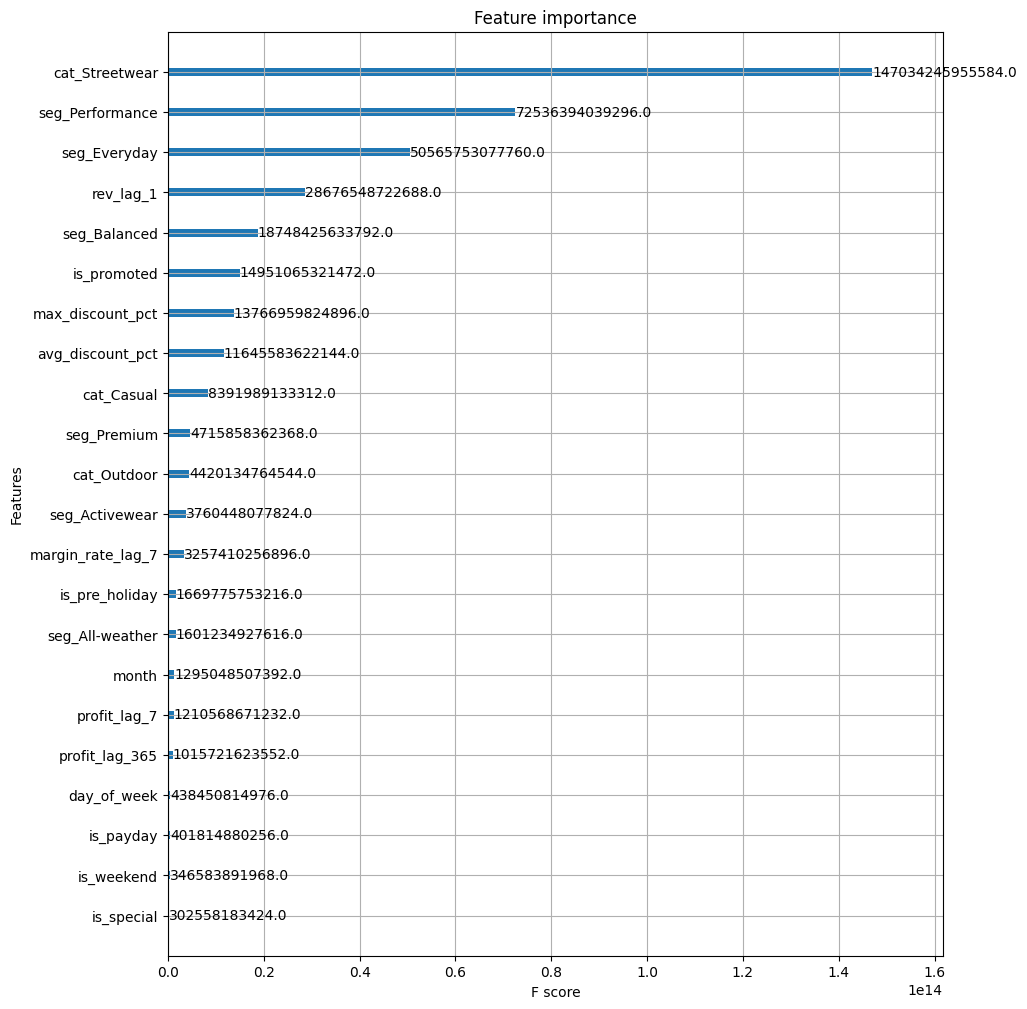

In [36]:
from xgboost import plot_importance

# 1. Train lại một model với bộ tham số xịn nhất Optuna vừa tìm được
best_model = XGBRegressor(**study.best_params)
best_model.fit(X_train, y_train)

# 2. Vẽ biểu đồ quan trọng theo GÁNH (Gain) - Cái này chuẩn hơn Weight
fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(best_model, importance_type='gain', ax=ax)
plt.show()

In [37]:
import xgboost as xgb

best_param={
    'n_estimators': 1381,
    'max_depth': 3, 
    'learning_rate': 0.015490364108594305, 
    'subsample': 0.6349397154351263, 
    'colsample_bytree': 0.6857173094570057, 
    'reg_alpha': 1.1585930474696895, 
    'reg_lambda': 0.03433161121687512
}
model_rev = XGBRegressor(**best_param)
model_rev.fit(df_daily[final_features], df_daily['Revenue'])

model_cogs= XGBRegressor(**best_param)
model_cogs.fit(df_daily[final_features], df_daily['COGS'])

print("✅ Đã huấn luyện xong bộ đôi 'não bộ' cho Model!")

from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import r2_score
tscv = TimeSeriesSplit(n_splits=5)
scoring = {'mse': 'neg_mean_squared_error', 'r2': 'r2'}

# Chấm điểm thử cho Model Revenue
cv_results = cross_validate(model_rev, df_daily[final_features], df_daily['Revenue'], 
                            cv=tscv, scoring=scoring)

# Tính toán các chỉ số trung bình từ kết quả CV
avg_mse = -cv_results['test_mse'].mean()
avg_rmse = np.sqrt(avg_mse)
avg_r2 = cv_results['test_r2'].mean()

print(f"📊 Kết quả Đánh giá 5-Fold:")
print(f"   - MSE:  {avg_mse:,.2f}")
print(f"   - RMSE: {avg_rmse:,.2f}")
print(f"   - R²:   {avg_r2:.4f}")

train_pred = model_rev.predict(df_daily[final_features])
train_r2 = r2_score(df_daily['Revenue'], train_pred)
print(f"Điểm trên tập Train: {train_r2:.4f}")

✅ Đã huấn luyện xong bộ đôi 'não bộ' cho Model!
📊 Kết quả Đánh giá 5-Fold:
   - MSE:  202,198,775,071.66
   - RMSE: 449,665.18
   - R²:   0.9656
Điểm trên tập Train: 0.9917


In [38]:
# ĐÁNH GIÁ MÔ HÌNH REVENUE
cv_rev = cross_validate(model_rev, df_daily[final_features], df_daily['Revenue'], 
                         cv=tscv, scoring=scoring)

# ĐÁNH GIÁ MÔ HÌNH COGS
cv_cogs = cross_validate(model_cogs, df_daily[final_features], df_daily['COGS'], 
                          cv=tscv, scoring=scoring)

# TỔNG KẾT KẾT QUẢ
print(f"[REVENUE] Local RMSE: {np.sqrt(-cv_rev['test_mse'].mean()):,.2f} | R²: {cv_rev['test_r2'].mean():.4f}")
print(f"[COGS]    Local RMSE: {np.sqrt(-cv_cogs['test_mse'].mean()):,.2f} | R²: {cv_cogs['test_r2'].mean():.4f}")

[REVENUE] Local RMSE: 449,665.18 | R²: 0.9656
[COGS]    Local RMSE: 342,618.31 | R²: 0.9683


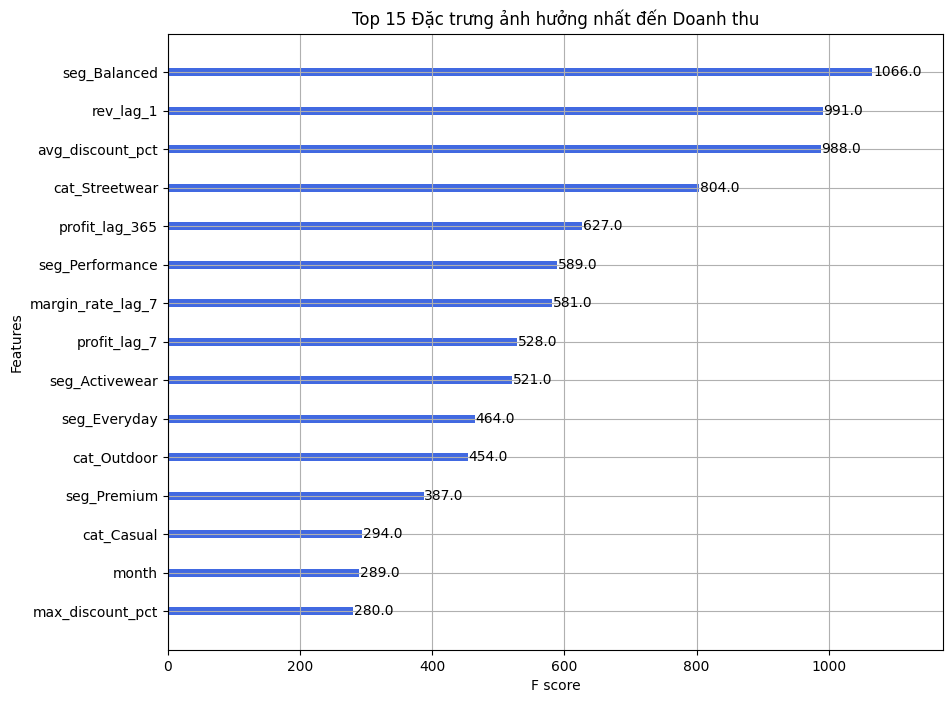

In [39]:
from xgboost import plot_importance

# 1. Thiết lập kích thước biểu đồ
fig, ax = plt.subplots(figsize=(10, 8))

# 2. Vẽ biểu đồ quan trọng (Dùng 'weight' để xem tần suất biến đó được dùng để phân loại)
plot_importance(model_rev, ax=ax, max_num_features=15, importance_type='weight', color='royalblue')

plt.title("Top 15 Đặc trưng ảnh hưởng nhất đến Doanh thu")
plt.show()

In [40]:
ALL_DATES = sorted(df_daily['Date'].unique())

def get_lag_safe(date_obj, lag_days, key, hist_dict):
    target_date = date_obj - pd.Timedelta(days=lag_days)
    
    if target_date in hist_dict:
        return hist_dict[target_date].get(key, 0)
    
    valid_dates = [d for d in ALL_DATES if d <= target_date]
    if valid_dates:
        closest_date = valid_dates[-1]
        if abs((closest_date - target_date).days) <= 3:
            return hist_dict.get(closest_date, {}).get(key, 0)
    return 0

In [41]:
from sklearn.metrics import mean_squared_error
from tqdm import tqdm

# Tạo tập validation (2 tháng cuối 2022)
val_start = '2022-11-01'
val_end = '2022-12-31'

# Lấy 400 ngày cuối cùng của tập train để làm lịch sử cho validation
historical_val = df_daily[['Date', 'Revenue', 'Profit']].iloc[-400:-30].copy()
historical_val = historical_val.rename(columns={'Date': 'ds', 'Revenue': 'y', 'Profit': 'profit'})
historical_val_dict = historical_val.set_index('ds').to_dict('index')

# Tạo đặc trưng tĩnh theo tháng
train_monthly_avg = df_daily.groupby('month')[
    ['is_promoted', 'avg_discount_pct', 'max_discount_pct',
     'cat_Casual', 'cat_Outdoor', 'cat_Streetwear',
     'seg_Activewear', 'seg_All-weather', 'seg_Balanced', 'seg_Everyday',
     'seg_Performance', 'seg_Premium']
].mean().to_dict('index')

# Tìm tỷ lệ blending tối ưu
best_score = float('inf')
best_ratio = 0.8
best_growth = 1.03

print("Đang tìm tỷ lệ blending tối ưu...")
for growth in [0.97, 0.98, 0.99, 1.0, 1.01, 1.02, 1.03, 1.04, 1.05]:
    for ratio in [0.45, 0.5, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
        val_results = []
        temp_dict = historical_val_dict.copy()
        
        for current_date in pd.date_range(start=val_start, end=val_end):
            month = current_date.month
            current_features = {
                'month': month,
                'day_of_week': current_date.dayofweek,
                'is_weekend': 1 if current_date.dayofweek >= 5 else 0,
                'is_special': get_special_event(current_date),
                'is_pre_holiday': get_pre_holiday_event(current_date),
                'is_payday': 1 if (current_date.day == 15 or current_date.is_month_end) else 0,
                'rev_lag_1': get_lag_safe(current_date, 1, 'y', temp_dict),
                'profit_lag_7': get_lag_safe(current_date, 7, 'profit', temp_dict),
                'profit_lag_365': get_lag_safe(current_date, 365, 'profit', temp_dict),
            }
            
            # Tính margin_rate_lag_7
            rev_lag_7 = get_lag_safe(current_date, 7, 'y', temp_dict)
            profit_lag_7_val = current_features['profit_lag_7']
            current_features['margin_rate_lag_7'] = profit_lag_7_val / (rev_lag_7 + 1)
            
            # Thêm đặc trưng tĩnh
            for k, v in train_monthly_avg.get(month, {}).items():
                current_features[k] = v
            
            X_pred = pd.DataFrame([current_features])[final_features]
            revenue_pred = model_rev.predict(X_pred)[0]
            cogs_pred = model_cogs.predict(X_pred)[0]
            
            hist_rev = get_lag_safe(current_date, 365, 'y', temp_dict)
            hist_cogs = hist_rev - get_lag_safe(current_date, 365, 'profit', temp_dict) if hist_rev > 0 else 0
            
            final_rev = (hist_rev * growth * ratio) + (revenue_pred * (1 - ratio))
            final_cogs = (hist_cogs * growth * ratio) + (cogs_pred * (1 - ratio))
            
            temp_dict[current_date] = {'y': final_rev, 'profit': final_rev - final_cogs}
            val_results.append({'Date': current_date, 'Revenue': final_rev, 'COGS': final_cogs})
        
        # Đánh giá
        val_df = pd.DataFrame(val_results)
        actual_train = df_daily[df_daily['Date'].between(val_start, val_end)]
        val_merged = val_df.merge(actual_train[['Date', 'Revenue', 'COGS']], on='Date', suffixes=('_pred', '_actual'))
        
        mse_rev = mean_squared_error(val_merged['Revenue_actual'], val_merged['Revenue_pred'])
        mse_cogs = mean_squared_error(val_merged['COGS_actual'], val_merged['COGS_pred'])
        total_mse = mse_rev + mse_cogs
        
        if total_mse < best_score:
            best_score = total_mse
            best_ratio = ratio
            best_growth = growth

print(f"\nTỶ LỆ BLENDING TỐI ƯU:")
print(f"   - History weight: {best_ratio:.0%}")
print(f"   - AI weight:      {1-best_ratio:.0%}")
print(f"   - Growth factor:  {best_growth}")
print(f"   - Best MSE:       {best_score:,.2f}")

Đang tìm tỷ lệ blending tối ưu...

TỶ LỆ BLENDING TỐI ƯU:
   - History weight: 45%
   - AI weight:      55%
   - Growth factor:  0.97
   - Best MSE:       738,210,277,674.55


In [42]:
from tqdm import tqdm

print("Bắt đầu quá trình dự đoán tuần tự...")

historical_df = df_daily[['Date', 'Revenue', 'Profit']].iloc[-370:].copy()
historical_df = historical_df.rename(columns={'Date': 'ds', 'Revenue': 'y', 'Profit': 'profit'})
historical_dict = historical_df.set_index('ds').to_dict('index')

future_dates = pd.date_range(start='2023-01-01', end='2024-07-01')
results = []

# Các đặc trưng tĩnh (không thay đổi theo thời gian hoặc lấy trung bình tháng)
train_monthly_avg = df_daily.groupby('month')[
    ['is_promoted', 'avg_discount_pct', 'max_discount_pct',
     'cat_Casual', 'cat_Outdoor', 'cat_Streetwear',
     'seg_Activewear', 'seg_All-weather', 'seg_Balanced', 'seg_Everyday',
     'seg_Performance', 'seg_Premium']
].mean().to_dict('index')

start_pred_date = pd.to_datetime('2023-01-01')
total_pred_days = 547
# Dự đoán tuần tự
for current_date in tqdm(future_dates, desc="Đang dự đoán"):
    month = current_date.month
    # Tạo feature cho ngày hiện tại
    current_features = {
        'month': month,
        'day_of_week': current_date.dayofweek,
        'is_weekend': 1 if current_date.dayofweek >= 5 else 0,
        'is_special': get_special_event(current_date),
        'is_pre_holiday': get_pre_holiday_event(current_date),
        'is_payday': 1 if (current_date.day == 15 or current_date.is_month_end) else 0,
        'profit_lag_365': get_lag_safe(current_date, 365, 'profit', historical_dict),
        'rev_lag_1': get_lag_safe(current_date, 1, 'y', historical_dict),
        'profit_lag_7': get_lag_safe(current_date, 7, 'profit', historical_dict),
        'margin_rate_lag_7': get_lag_safe(current_date, 7, 'profit', historical_dict) / (get_lag_safe(current_date, 7, 'y', historical_dict) + 1)
    }
    
    # Thêm các đặc trưng tĩnh từ dữ liệu trung bình tháng
    for k, v in train_monthly_avg.get(month, {}).items():
        current_features[k] = v

    # Dự đoán Doanh thu và Giá vốn
    X_pred = pd.DataFrame([current_features])[final_features]
    revenue_pred = model_rev.predict(X_pred)[0]
    cogs_pred = model_cogs.predict(X_pred)[0]

    # Blending
    hist_rev = get_lag_safe(current_date, 365, 'y', historical_dict)
    hist_cogs = hist_rev - get_lag_safe(current_date, 365, 'profit', historical_dict) if hist_rev > 0 else 0
    days_passed = (current_date - start_pred_date).days
    ai_weight = 0.85 - (0.60 * (days_passed / total_pred_days))
    hist_weight = 1.0 - ai_weight

    growth_factor = 1.00
    final_rev = (hist_rev * growth_factor * hist_weight) + (revenue_pred * ai_weight)
    final_cogs = (hist_cogs * growth_factor * hist_weight) + (cogs_pred * ai_weight)

    # Cập nhật kết quả vào historical_dict cho các lần dự đoán tiếp theo
    historical_dict[current_date] = {'y': final_rev, 'profit': final_rev - final_cogs}
    
    # Lưu kết quả
    results.append({
        'Date': current_date.strftime('%Y-%m-%d'),
        'Revenue': final_rev,
        'COGS': final_cogs
    })

# Tạo và lưu file submission
submission_final = pd.DataFrame(results)
submission_final.to_csv('submission_khang_fixed_v14.csv', index=False)
print(f"✅ File 'submission_khang_fixed_v14.csv' đã sẵn sàng nộp.")

Bắt đầu quá trình dự đoán tuần tự...


Đang dự đoán: 100%|██████████| 548/548 [00:03<00:00, 176.83it/s]

✅ File 'submission_khang_fixed_v14.csv' đã sẵn sàng nộp.
